# Red de Bicipuma de CU

In [2]:
import numpy as np
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
nodos = {
    "Anexo Filosofía y Letras (Palomar)":(0,6),
    "Estadio":(1.9,4),
    "Filosofía y Letras": (3, 6),
    "Derecho": (5, 6),
    "Medicina": (7, 5.5),
    "Química": (6, 3.5),
    "Ciencias": (7.2, 0),
    "Anexo de Ingeniería":(4.8,1.5),
    "Ciencias Políticas y Sociales": (8.5, -3),
    "Arquitectura": (3, 4.1),
    "Ingeniería": (4.5, 4),
    "Estadio Tapatío Méndez": (2.4, 0),
    "Bicicentro": (9, 0),
    "Posgrado de Economía": (3,-7),
}

In [4]:
aristas = [
    ("Anexo Filosofía y Letras (Palomar)", "Estadio"),
    ("Anexo Filosofía y Letras (Palomar)", "Arquitectura"),
    ("Estadio", "Arquitectura"),
    ("Arquitectura", "Filosofía y Letras"),
    ("Filosofía y Letras", "Derecho"),
    ("Derecho", "Medicina"),
    ("Medicina", "Química"),
    ("Química", "Anexo de Ingeniería"),
    ("Anexo de Ingeniería", "Estadio Tapatío Méndez"),
    ("Ciencias", "Estadio Tapatío Méndez"),
    ("Anexo de Ingeniería", "Ciencias"),
    ("Ciencias", "Bicicentro"),
    ("Bicicentro", "Ciencias Políticas y Sociales"),
    ("Arquitectura", "Ingeniería"),
    ("Ingeniería", "Derecho"),
    ("Anexo de Ingeniería", "Ingeniería"),
    ("Ciencias Políticas y Sociales","Posgrado de Economía")
]

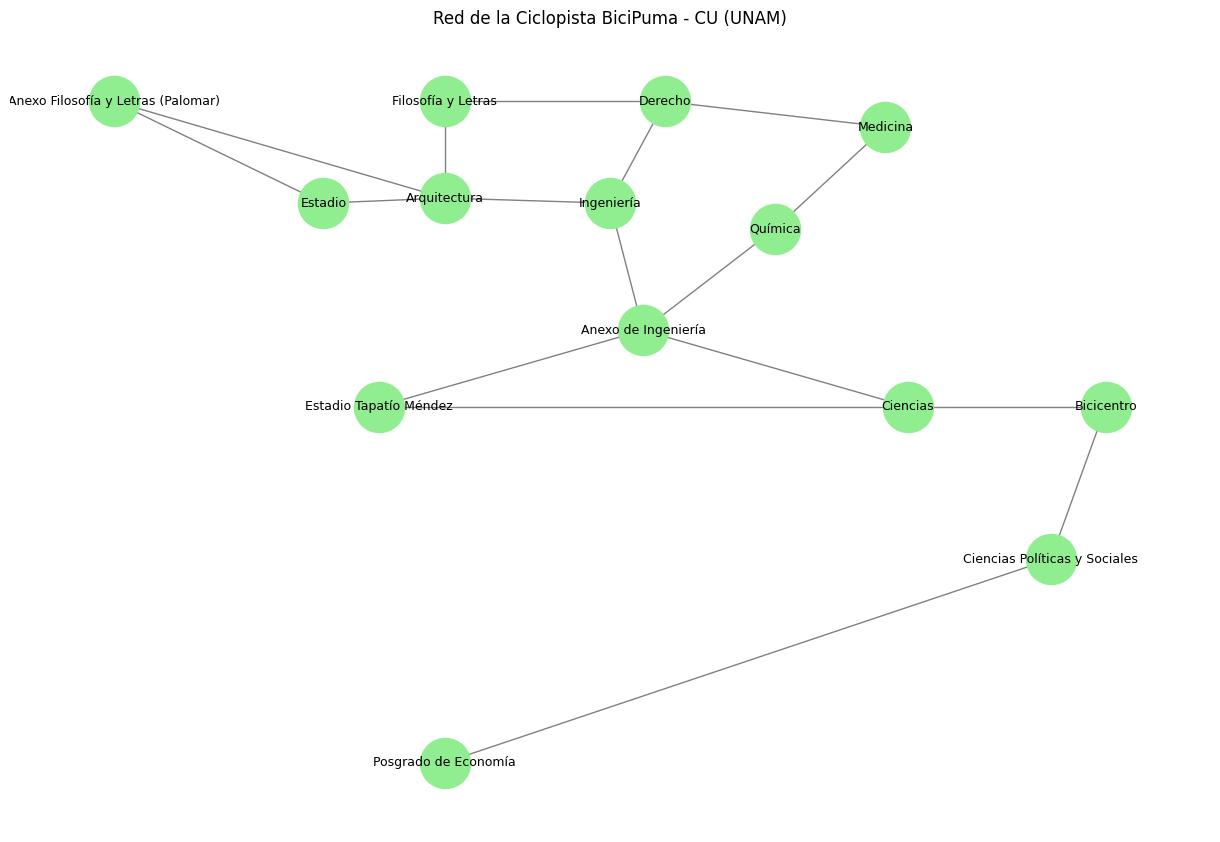

In [5]:
G = nx.Graph()

# Añadir nodos con posición
for nodo, pos in nodos.items():
    G.add_node(nodo, pos=pos)

# Añadir aristas
G.add_edges_from(aristas)

# Graficar
pos = nx.get_node_attributes(G, 'pos')
plt.figure(figsize=(12, 8))
nx.draw(G, pos, with_labels=True, node_color='lightgreen', node_size=1300, font_size=9, edge_color='gray')
plt.title("Red de la Ciclopista BiciPuma - CU (UNAM)")
plt.show()

# Algoritmo de Floyd

In [6]:
def algoritmoFloyd(D0):
  """
  Función que aplica el algoritmo de Floyd-Warshall a una red dada.
  :param D0: Matriz de distancias inicial.
  :return: Matriz de distancias final y matriz de caminos final.
  """
  n = D0.shape[0]
  R0 = np.zeros((n,n))
  for i in range(n):
    for j in range(n):
      R0[i,j] = j+1
  Di = np.copy(D0)
  Ri = np.copy(R0)

  for k in range(n):
    for i in range(n):
      for j in range(n):
        if Di[i, k] != np.inf and Di[k, j] != np.inf and Di[i, j] > Di[i, k] + Di[k, j]:
          Di[i, j] = Di[i, k] + Di[k, j]
          Ri[i, j] = Ri[i, k]
    print(f"Iteración k = {k+1}:")
    print(f"Matriz de distancias D_{k+1}:")
    display(Di)
    print(f"Matriz de rutas R_{k+1}:")
    display(Ri)

In [7]:
# Matriz de costos de la red bicipuma
RedBicipuma = np.array([
    [0, 2100, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf,np.inf],
    [2100, 0, 800, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf],
    [np.inf, 800, 0, 600, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf],
    [np.inf, np.inf, 600, 0, 1300, 850, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf],
    [np.inf, np.inf, np.inf, 1300, 0, 800, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf],
    [np.inf, np.inf, np.inf, 850, 800, 0, 400, np.inf, np.inf, 600, np.inf, np.inf, np.inf, np.inf],
    [np.inf, np.inf, np.inf, np.inf, np.inf, 400, 0, 500, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf],
    [np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, 500, 0, 400, np.inf, np.inf, np.inf, np.inf, np.inf],
    [np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, 400, 0, 290, 350, np.inf, np.inf, np.inf],
    [np.inf, np.inf, np.inf, np.inf, np.inf, 600, np.inf, np.inf, 290, 0, np.inf, 500, np.inf, np.inf],
    [np.inf, np.inf, np.inf, np.inf, np.inf, 600, np.inf, np.inf, 350, np.inf, 0, 270, np.inf, np.inf],
    [np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, 500, 270, 0, 300, 1400],
    [np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, 300, 0, 1300],
    [np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf,  np.inf, np.inf, 1400, 1300, 0]
])

In [8]:
# Aplicar algoritmo de Floyd a la red original
algoritmoFloyd(RedBicipuma)

Iteración k = 1:
Matriz de distancias D_1:


array([[   0., 2100.,   inf,   inf,   inf,   inf,   inf,   inf,   inf,
          inf,   inf,   inf,   inf,   inf],
       [2100.,    0.,  800.,   inf,   inf,   inf,   inf,   inf,   inf,
          inf,   inf,   inf,   inf,   inf],
       [  inf,  800.,    0.,  600.,   inf,   inf,   inf,   inf,   inf,
          inf,   inf,   inf,   inf,   inf],
       [  inf,   inf,  600.,    0., 1300.,  850.,   inf,   inf,   inf,
          inf,   inf,   inf,   inf,   inf],
       [  inf,   inf,   inf, 1300.,    0.,  800.,   inf,   inf,   inf,
          inf,   inf,   inf,   inf,   inf],
       [  inf,   inf,   inf,  850.,  800.,    0.,  400.,   inf,   inf,
         600.,   inf,   inf,   inf,   inf],
       [  inf,   inf,   inf,   inf,   inf,  400.,    0.,  500.,   inf,
          inf,   inf,   inf,   inf,   inf],
       [  inf,   inf,   inf,   inf,   inf,   inf,  500.,    0.,  400.,
          inf,   inf,   inf,   inf,   inf],
       [  inf,   inf,   inf,   inf,   inf,   inf,   inf,  400.,    0.,
         

Matriz de rutas R_1:


array([[ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
        14.],
       [ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
        14.],
       [ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
        14.],
       [ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
        14.],
       [ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
        14.],
       [ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
        14.],
       [ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
        14.],
       [ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
        14.],
       [ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
        14.],
       [ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
        14.],
       [ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
        14.],
       [ 1.,  2.,  3.,  4.,  5.,  6.,  7., 

Iteración k = 2:
Matriz de distancias D_2:


...

array([[ 1.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,
         2.],
       [ 1.,  2.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,
         3.],
       [ 2.,  2.,  3.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,
         4.],
       [ 3.,  3.,  3.,  4.,  5.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,
         6.],
       [ 4.,  4.,  4.,  4.,  5.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,
         6.],
       [ 4.,  4.,  4.,  4.,  5.,  6.,  7.,  7., 10., 10., 10., 10., 10.,
        10.],
       [ 6.,  6.,  6.,  6.,  6.,  6.,  7.,  8.,  8.,  6.,  8.,  6.,  6.,
         6.],
       [ 7.,  7.,  7.,  7.,  7.,  7.,  7.,  8.,  9.,  9.,  9.,  9.,  9.,
         9.],
       [10., 10., 10., 10., 10., 10.,  8.,  8.,  9., 10., 11., 11., 11.,
        11.],
       [ 6.,  6.,  6.,  6.,  6.,  6.,  6.,  9.,  9., 10.,  9., 12., 12.,
        12.],
       [ 6.,  6.,  6.,  6.,  6.,  6.,  6.,  9.,  9.,  9., 11., 12., 12.,
        12.],
       [11., 11., 11., 11., 11., 11., 11., 

Iteración k = 14:
Matriz de distancias D_14:


array([[   0., 2100., 2900., 3500., 4800., 4350., 4750., 5250., 5240.,
        4950., 5590., 5450., 5750., 6850.],
       [2100.,    0.,  800., 1400., 2700., 2250., 2650., 3150., 3140.,
        2850., 3490., 3350., 3650., 4750.],
       [2900.,  800.,    0.,  600., 1900., 1450., 1850., 2350., 2340.,
        2050., 2690., 2550., 2850., 3950.],
       [3500., 1400.,  600.,    0., 1300.,  850., 1250., 1750., 1740.,
        1450., 2090., 1950., 2250., 3350.],
       [4800., 2700., 1900., 1300.,    0.,  800., 1200., 1700., 1690.,
        1400., 2040., 1900., 2200., 3300.],
       [4350., 2250., 1450.,  850.,  800.,    0.,  400.,  900.,  890.,
         600., 1240., 1100., 1400., 2500.],
       [4750., 2650., 1850., 1250., 1200.,  400.,    0.,  500.,  900.,
        1000., 1250., 1500., 1800., 2900.],
       [5250., 3150., 2350., 1750., 1700.,  900.,  500.,    0.,  400.,
         690.,  750., 1020., 1320., 2420.],
       [5240., 3140., 2340., 1740., 1690.,  890.,  900.,  400.,    0.,
         

Matriz de rutas R_14:


array([[ 1.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,
         2.],
       [ 1.,  2.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,
         3.],
       [ 2.,  2.,  3.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,  4.,
         4.],
       [ 3.,  3.,  3.,  4.,  5.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,
         6.],
       [ 4.,  4.,  4.,  4.,  5.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,
         6.],
       [ 4.,  4.,  4.,  4.,  5.,  6.,  7.,  7., 10., 10., 10., 10., 10.,
        10.],
       [ 6.,  6.,  6.,  6.,  6.,  6.,  7.,  8.,  8.,  6.,  8.,  6.,  6.,
         6.],
       [ 7.,  7.,  7.,  7.,  7.,  7.,  7.,  8.,  9.,  9.,  9.,  9.,  9.,
         9.],
       [10., 10., 10., 10., 10., 10.,  8.,  8.,  9., 10., 11., 11., 11.,
        11.],
       [ 6.,  6.,  6.,  6.,  6.,  6.,  6.,  9.,  9., 10.,  9., 12., 12.,
        12.],
       [ 6.,  6.,  6.,  6.,  6.,  6.,  6.,  9.,  9.,  9., 11., 12., 12.,
        12.],
       [11., 11., 11., 11., 11., 11., 11., 

# Medidas de centralidad

In [9]:
# Convertir la matriz a un objeto de grafo de NetworkX
G = nx.from_numpy_array(RedBicipuma)

# Calcular la Centralidad intermedia
betweenness_centrality = nx.betweenness_centrality(G, weight='weight')

# Calcular la Centralidad de cercanía
closeness_centrality = nx.closeness_centrality(G, distance='weight')

results = pd.DataFrame({
    "Centralidad intermedia": betweenness_centrality,
    "Centralidad de cercanía": closeness_centrality
}).sort_index()

print(results)

    Centralidad intermedia  Centralidad de cercanía
0                 0.000000                 0.000216
1                 0.153846                 0.000372
2                 0.282051                 0.000482
3                 0.384615                 0.000587
4                 0.000000                 0.000508
5                 0.576923                 0.000747
6                 0.076923                 0.000619
7                 0.012821                 0.000586
8                 0.076923                 0.000633
9                 0.076923                 0.000680
10                0.346154                 0.000701
11                0.282051                 0.000640
12                0.000000                 0.000553
13                0.000000                 0.000354


## Longitud promedio del camino y diámetro

In [31]:
APL = nx.average_shortest_path_length(G, weight='weight')
print("Longitud promedio del camino: ", APL)
diam = nx.diameter(G, weight='weight')
print("Diámetro de la gráfica", diam)

Longitud promedio del camino:  2028.131868131868
Diámetro de la gráfica 6620.0


# Propuesta red BICIPUMA

In [11]:
nodos2 = {
    "Anexo Filosofía y Letras (Palomar)":(0,6),
    "Estadio":(1.9,4),
    "Filosofía y Letras": (3, 6),
    "Derecho": (5, 6),
    "Medicina": (7, 5.5),
    "Química": (6, 3.5),
    "Ciencias": (7.2, 0),
    "Anexo de Ingeniería":(4.8,1.5),
    "Ciencias Políticas y Sociales": (8.5, -3),
    "Arquitectura": (3, 4.1),
    "Ingeniería": (4.5, 4),
    "Estadio Tapatío Méndez": (2.4, 0),
    "Bicicentro": (9, 0),
    "Posgrado de Economía": (4,-7),
    "UNIVERSUM": (7, -7),
    "MB Zona Cultural": (3.5,-4.5),
    "MB Ciudad Universitaria": (2.4, -2.1),
    "Pista de Calentamiento": (0, 2.3),
    "DEP": (8, 2.75)
}

In [12]:
aristas2 = [
    ("Anexo Filosofía y Letras (Palomar)", "Estadio"),
    ("Anexo Filosofía y Letras (Palomar)", "Arquitectura"),
    ("Estadio", "Arquitectura"),
    ("Arquitectura", "Filosofía y Letras"),
    ("Filosofía y Letras", "Derecho"),
    ("Derecho", "Medicina"),
    ("Medicina", "Química"),
    ("Química", "Anexo de Ingeniería"),
    ("Anexo de Ingeniería", "Estadio Tapatío Méndez"),
    ("Ciencias", "Estadio Tapatío Méndez"),
    ("Anexo de Ingeniería", "Ciencias"),
    ("Ciencias", "Bicicentro"),
    ("Bicicentro", "Ciencias Políticas y Sociales"),
    ("Arquitectura", "Ingeniería"),
    ("Ingeniería", "Derecho"),
    ("Anexo de Ingeniería", "Ingeniería"),
    ("Ciencias Políticas y Sociales","UNIVERSUM"),
    ("UNIVERSUM","Posgrado de Economía"),
    ("Posgrado de Economía", "MB Zona Cultural"),
    ("MB Zona Cultural","MB Ciudad Universitaria"),
    ("MB Zona Cultural","Ciencias Políticas y Sociales"),
    ("MB Ciudad Universitaria","Pista de Calentamiento"),
    ("Pista de Calentamiento","Anexo Filosofía y Letras (Palomar)"),
    ("Bicicentro", "DEP"),
    ("DEP", "Medicina"),
    ("Estadio Tapatío Méndez", "Pista de Calentamiento")
]

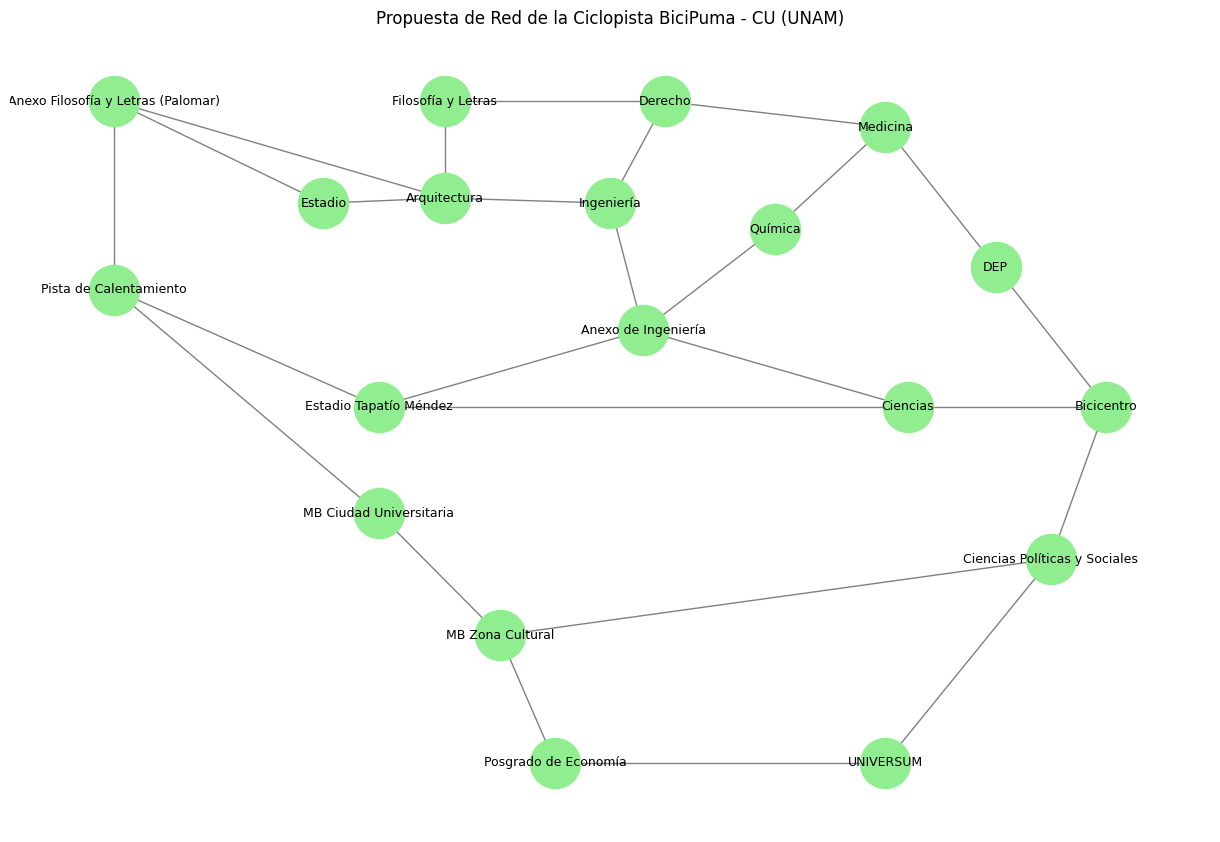

In [13]:
G2 = nx.Graph()

# Añadir nodos con posición
for nodo, pos in nodos2.items():
    G2.add_node(nodo, pos=pos)

# Añadir aristas
G2.add_edges_from(aristas2)

# Graficar
pos = nx.get_node_attributes(G2, 'pos')
plt.figure(figsize=(12, 8))
nx.draw(G2, pos, with_labels=True, node_color='lightgreen', node_size=1300, font_size=9, edge_color='gray')
plt.title("Propuesta de Red de la Ciclopista BiciPuma - CU (UNAM)")
plt.show()

In [14]:
# Definir matriz de costos para la red propuesta
RedBicipuma2 = np.array([
    [0, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf,np.inf, 700, 450, np.inf, np.inf, np.inf],
    [np.inf, 0, 800, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, 1400, 1700, np.inf, np.inf, np.inf],
    [np.inf, 800, 0, 600, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, 550, np.inf],
    [np.inf, np.inf, 600, 0, 1300, 850, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf],
    [np.inf, np.inf, np.inf, 1300, 0, 800, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, 1800],
    [np.inf, np.inf, np.inf, 850, 800, 0, 400, np.inf, np.inf, 600, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf],
    [np.inf, np.inf, np.inf, np.inf, np.inf, 400, 0, 500, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf],
    [np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, 500, 0, 400, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, 1600, np.inf],
    [np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, 400, 0, 290, 350, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf],
    [np.inf, np.inf, np.inf, np.inf, np.inf, 600, np.inf, np.inf, 290, 0, np.inf, 500, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf],
    [np.inf, np.inf, np.inf, np.inf, np.inf, 600, np.inf, np.inf, 350, np.inf, 0, 270, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf],
    [np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, 500, 270, 0, 300, 1400, np.inf, np.inf, np.inf, np.inf, np.inf],
    [np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, 300, 0, 1300, np.inf, np.inf, np.inf, np.inf, np.inf],
    [np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf,  np.inf, np.inf, 1400, 1300, 0, np.inf, np.inf, np.inf, np.inf, 1200],
    [700, 1400, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, 0, np.inf, np.inf, np.inf, np.inf],
    [450, 1700, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, 0, 1700, np.inf, np.inf],
    [np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, 1700, 0, np.inf, 1800],
    [np.inf, np.inf, 550, np.inf, np.inf, np.inf, np.inf, 1600, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, 0, np.inf],
    [np.inf, np.inf, np.inf, np.inf, 1800, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf, 1200, np.inf, np.inf, 1800, np.inf, 0]
])

In [15]:
# Aplicar algoritmo de Floyd para la red propuesta
algoritmoFloyd(RedBicipuma2)

Iteración k = 1:
Matriz de distancias D_1:


array([[   0.,   inf,   inf,   inf,   inf,   inf,   inf,   inf,   inf,
          inf,   inf,   inf,   inf,   inf,  700.,  450.,   inf,   inf,
          inf],
       [  inf,    0.,  800.,   inf,   inf,   inf,   inf,   inf,   inf,
          inf,   inf,   inf,   inf,   inf, 1400., 1700.,   inf,   inf,
          inf],
       [  inf,  800.,    0.,  600.,   inf,   inf,   inf,   inf,   inf,
          inf,   inf,   inf,   inf,   inf,   inf,   inf,   inf,  550.,
          inf],
       [  inf,   inf,  600.,    0., 1300.,  850.,   inf,   inf,   inf,
          inf,   inf,   inf,   inf,   inf,   inf,   inf,   inf,   inf,
          inf],
       [  inf,   inf,   inf, 1300.,    0.,  800.,   inf,   inf,   inf,
          inf,   inf,   inf,   inf,   inf,   inf,   inf,   inf,   inf,
        1800.],
       [  inf,   inf,   inf,  850.,  800.,    0.,  400.,   inf,   inf,
         600.,   inf,   inf,   inf,   inf,   inf,   inf,   inf,   inf,
          inf],
       [  inf,   inf,   inf,   inf,   inf,  400.,   

Matriz de rutas R_1:


array([[ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
        14., 15., 16., 17., 18., 19.],
       [ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
        14., 15., 16., 17., 18., 19.],
       [ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
        14., 15., 16., 17., 18., 19.],
       [ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
        14., 15., 16., 17., 18., 19.],
       [ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
        14., 15., 16., 17., 18., 19.],
       [ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
        14., 15., 16., 17., 18., 19.],
       [ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
        14., 15., 16., 17., 18., 19.],
       [ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
        14., 15., 16., 17., 18., 19.],
       [ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
        14., 15., 16., 17., 18.

Iteración k = 2:
Matriz de distancias D_2:


...

array([[ 1., 15., 15., 15., 15., 15., 15., 15., 15., 15., 15., 15., 15.,
        15., 15., 16., 16., 15., 16.],
       [15.,  2.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,
         3., 15., 16., 16.,  3.,  3.],
       [ 2.,  2.,  3.,  4.,  4.,  4.,  4., 18.,  4.,  4.,  4.,  4.,  4.,
         4.,  2.,  2.,  2., 18.,  4.],
       [ 3.,  3.,  3.,  4.,  5.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,
         6.,  3.,  3.,  3.,  3.,  5.],
       [ 4.,  4.,  4.,  4.,  5.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,
         6.,  4.,  4.,  4.,  4., 19.],
       [ 4.,  4.,  4.,  4.,  5.,  6.,  7.,  7., 10., 10., 10., 10., 10.,
        10.,  4.,  4.,  4.,  4.,  5.],
       [ 6.,  6.,  6.,  6.,  6.,  6.,  7.,  8.,  8.,  6.,  8.,  6.,  6.,
         6.,  6.,  6.,  6.,  8.,  6.],
       [18., 18., 18.,  7.,  7.,  7.,  7.,  8.,  9.,  9.,  9.,  9.,  9.,
         9., 18., 18., 18., 18.,  7.],
       [10., 10., 10., 10., 10., 10.,  8.,  8.,  9., 10., 11., 11., 11.,
        11., 10., 10., 10.,  8.

Iteración k = 19:
Matriz de distancias D_19:


array([[   0., 2100., 2900., 3500., 4800., 4350., 4750., 5050., 5240.,
        4950., 5590., 5450., 5750., 5150.,  700.,  450., 2150., 3450.,
        3950.],
       [2100.,    0.,  800., 1400., 2700., 2250., 2650., 2950., 3140.,
        2850., 3490., 3350., 3650., 4750., 1400., 1700., 3400., 1350.,
        4500.],
       [2900.,  800.,    0.,  600., 1900., 1450., 1850., 2150., 2340.,
        2050., 2690., 2550., 2850., 3950., 2200., 2500., 4200.,  550.,
        3700.],
       [3500., 1400.,  600.,    0., 1300.,  850., 1250., 1750., 1740.,
        1450., 2090., 1950., 2250., 3350., 2800., 3100., 4800., 1150.,
        3100.],
       [4800., 2700., 1900., 1300.,    0.,  800., 1200., 1700., 1690.,
        1400., 2040., 1900., 2200., 3000., 4100., 4400., 3600., 2450.,
        1800.],
       [4350., 2250., 1450.,  850.,  800.,    0.,  400.,  900.,  890.,
         600., 1240., 1100., 1400., 2500., 3650., 3950., 4400., 2000.,
        2600.],
       [4750., 2650., 1850., 1250., 1200.,  400.,   

Matriz de rutas R_19:


array([[ 1., 15., 15., 15., 15., 15., 15., 15., 15., 15., 15., 15., 15.,
        16., 15., 16., 16., 15., 16.],
       [15.,  2.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,  3.,
         3., 15., 16., 16.,  3.,  3.],
       [ 2.,  2.,  3.,  4.,  4.,  4.,  4., 18.,  4.,  4.,  4.,  4.,  4.,
         4.,  2.,  2.,  2., 18.,  4.],
       [ 3.,  3.,  3.,  4.,  5.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,
         6.,  3.,  3.,  3.,  3.,  5.],
       [ 4.,  4.,  4.,  4.,  5.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,  6.,
        19.,  4.,  4., 19.,  4., 19.],
       [ 4.,  4.,  4.,  4.,  5.,  6.,  7.,  7., 10., 10., 10., 10., 10.,
        10.,  4.,  4.,  5.,  4.,  5.],
       [ 6.,  6.,  6.,  6.,  6.,  6.,  7.,  8.,  8.,  6.,  8.,  6.,  6.,
         6.,  6.,  6.,  6.,  8.,  6.],
       [18., 18., 18.,  7.,  7.,  7.,  7.,  8.,  9.,  9.,  9.,  9.,  9.,
         9., 18., 18.,  7., 18.,  7.],
       [10., 10., 10., 10., 10., 10.,  8.,  8.,  9., 10., 11., 11., 11.,
        11., 10., 10., 11.,  8.

## Medidas de centralidad red propuesta

In [34]:
# Convertir la matriz a un objeto de grafo de NetworkX
G2 = nx.from_numpy_array(RedBicipuma2)

# Calcular la Centralidad intermedia
betweenness_centrality = nx.betweenness_centrality(G2, weight='weight')

# Calcular la Centralidad de cercanía
closeness_centrality = nx.closeness_centrality(G2, distance='weight')

results = pd.DataFrame({
    "Centralidad intermedia": betweenness_centrality,
    "Centralidad de cercanía": closeness_centrality
}).sort_index()

print(results)

    Centralidad intermedia  Centralidad de cercanía
0                 0.026144                 0.000260
1                 0.254902                 0.000382
2                 0.339869                 0.000451
3                 0.307190                 0.000485
4                 0.065359                 0.000430
5                 0.366013                 0.000529
6                 0.032680                 0.000458
7                 0.052288                 0.000439
8                 0.071895                 0.000448
9                 0.052288                 0.000471
10                0.222222                 0.000483
11                0.196078                 0.000458
12                0.000000                 0.000417
13                0.065359                 0.000334
14                0.084967                 0.000286
15                0.065359                 0.000285
16                0.039216                 0.000257
17                0.032680                 0.000394
18          

## Longitud promedio del camino y diámetro

In [35]:
APL2 = nx.average_shortest_path_length(G2, weight='weight')
print("Longitud promedio del camino: ", APL2)
diam2 = nx.diameter(G2, weight='weight')
print("Diámetro de la gráfica: ", diam2)

Longitud promedio del camino:  2628.4210526315787
Diámetro de la gráfica:  5850.0


# Robustez

In [38]:
def analizar_impacto_nodo(grafo, nombre_red, nodo_objetivo):
    """
    Analiza qué pasa con una red si se elimina un nodo específico.
    Comparando métricas antes y después del fallo.
    """
    print(f"--- ANÁLISIS DE FALLO: {nombre_red} ---")
    print(f"Objetivo: Eliminar nodo '{nodo_objetivo}'")

    # Verificar que el nodo existe
    if nodo_objetivo not in grafo:
        print(f"Error: El nodo '{nodo_objetivo}' no existe en esta red.\n")
        return

    # Métricas antes del fallo
    if nx.is_connected(grafo):
        apl_base = nx.average_shortest_path_length(grafo, weight='weight')
        diam_base = nx.diameter(grafo, weight='weight')
        print(f"  - Longitud promedio de viaje: {apl_base:.2f} m")
    else:
        print("La gráfica no es conexa")
        apl_base = None

    # Simular el fallo
    H = grafo.copy()
    H.remove_node(nodo_objetivo)

    # Cálculo de métricas después del fallo
    if nx.is_connected(H):
        apl_fail = nx.average_shortest_path_length(H, weight='weight')
        diam_fail = nx.diameter(H, weight='weight')
        if apl_base:
            aumento = ((apl_fail - apl_base) / apl_base) * 100
            print(f"ESTADO POST-FALLO:")
            print(f"  - Nueva longitud promedio: {apl_fail:.2f} m")
            print(f"  - Impacto en eficiencia: +{aumento:.2f}% más distancia")
            print(f"  - Nuevo diámetro: {diam_fail:.0f} m")

    print("-" * 40 + "\n")

In [39]:
# Facultad de Ciencias
nodo_critico = 3

# Analizar Red Original
analizar_impacto_nodo(G, "Red Bicipuma ACTUAL", nodo_critico)

# Analizar Red Propuesta
analizar_impacto_nodo(G2, "Red Bicipuma PROPUESTA", nodo_critico)

--- ANÁLISIS DE FALLO: Red Bicipuma ACTUAL ---
Objetivo: Eliminar nodo '3'
  - Longitud promedio de viaje: 2028.13 m
ESTADO POST-FALLO:
  - Nueva longitud promedio: inf m
  - Impacto en eficiencia: +inf% más distancia
  - Nuevo diámetro: inf m
----------------------------------------

--- ANÁLISIS DE FALLO: Red Bicipuma PROPUESTA ---
Objetivo: Eliminar nodo '3'
  - Longitud promedio de viaje: 2628.42 m
ESTADO POST-FALLO:
  - Nueva longitud promedio: 2982.75 m
  - Impacto en eficiencia: +13.48% más distancia
  - Nuevo diámetro: 6370 m
----------------------------------------



In [40]:
# Anexo de ingeniería
nodo_critico2 = 5

# Analizar red original
analizar_impacto_nodo(G, "Red Bicipuma ACTUAL", nodo_critico2)

# Analizar red propuesta
analizar_impacto_nodo(G2, "Red Bicipuma PROPUESTA", nodo_critico2)

--- ANÁLISIS DE FALLO: Red Bicipuma ACTUAL ---
Objetivo: Eliminar nodo '5'
  - Longitud promedio de viaje: 2028.13 m
ESTADO POST-FALLO:
  - Nueva longitud promedio: inf m
  - Impacto en eficiencia: +inf% más distancia
  - Nuevo diámetro: inf m
----------------------------------------

--- ANÁLISIS DE FALLO: Red Bicipuma PROPUESTA ---
Objetivo: Eliminar nodo '5'
  - Longitud promedio de viaje: 2628.42 m
ESTADO POST-FALLO:
  - Nueva longitud promedio: 3113.99 m
  - Impacto en eficiencia: +18.47% más distancia
  - Nuevo diámetro: 6370 m
----------------------------------------



In [41]:
# Facultad de Filosofía y Letras
nodo_critico = 10

# Analizar Red Original
analizar_impacto_nodo(G, "Red Bicipuma ACTUAL", nodo_critico)

# Analizar Red Propuesta
analizar_impacto_nodo(G2, "Red Bicipuma PROPUESTA", nodo_critico)

--- ANÁLISIS DE FALLO: Red Bicipuma ACTUAL ---
Objetivo: Eliminar nodo '10'
  - Longitud promedio de viaje: 2028.13 m
ESTADO POST-FALLO:
  - Nueva longitud promedio: 2203.33 m
  - Impacto en eficiencia: +8.64% más distancia
  - Nuevo diámetro: 6850 m
----------------------------------------

--- ANÁLISIS DE FALLO: Red Bicipuma PROPUESTA ---
Objetivo: Eliminar nodo '10'
  - Longitud promedio de viaje: 2628.42 m
ESTADO POST-FALLO:
  - Nueva longitud promedio: 2741.05 m
  - Impacto en eficiencia: +4.28% más distancia
  - Nuevo diámetro: 5850 m
----------------------------------------



In [42]:
# Facultad de Arquitectura
nodo_critico = 11

# Analizar Red Original
analizar_impacto_nodo(G, "Red Bicipuma ACTUAL", nodo_critico)

# Analizar Red Propuesta
analizar_impacto_nodo(G2, "Red Bicipuma PROPUESTA", nodo_critico)

--- ANÁLISIS DE FALLO: Red Bicipuma ACTUAL ---
Objetivo: Eliminar nodo '11'
  - Longitud promedio de viaje: 2028.13 m
ESTADO POST-FALLO:
  - Nueva longitud promedio: inf m
  - Impacto en eficiencia: +inf% más distancia
  - Nuevo diámetro: inf m
----------------------------------------

--- ANÁLISIS DE FALLO: Red Bicipuma PROPUESTA ---
Objetivo: Eliminar nodo '11'
  - Longitud promedio de viaje: 2628.42 m
ESTADO POST-FALLO:
  - Nueva longitud promedio: 3127.39 m
  - Impacto en eficiencia: +18.98% más distancia
  - Nuevo diámetro: 7150 m
----------------------------------------

